# Spyglass Tutorial: Gonzalez-Sulser GRIN2B Dataset

This notebook demonstrates querying the Gonzalez-Sulser lab's chronic EEG/EMG dataset (GRIN2B line, [DANDI:001888](https://dandiarchive.org/dandiset/001888)) **entirely through the Spyglass database** — targeting the draft `common_eeg`/`ImportedEEG` schema ([LorenFrankLab/spyglass#1638](https://github.com/LorenFrankLab/spyglass/pull/1638)).

It is deliberately written as if you have **no prior knowledge of, or access to, the original converted NWB files** — every query, completeness check, and plot below is produced from DataJoint tables and Spyglass's own data-recovery machinery (`fetch_nwb()` / `nwb_object()`), not from reading a source `.nwb` path directly.

**Two things this notebook demonstrates:**
1. **Completeness** — recover the session, subject, electrode, and EEG-series tables for every inserted subject and verify nothing is missing.
2. **Manipulability** — recover actual trace data from the database and use it: a multi-channel snippet for one subject, then the *same* channel overlaid across *every* subject.

**Prerequisites**: the Spyglass MySQL container running (`docker compose up -d` in `spyglass/`) and the `spyglass-eeg` conda env active (`spyglass` installed from the PR #1638 branch — see `../spyglass_ingestion_notes.md`).

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import datajoint as dj
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Works whether this notebook is run from `spyglass/` or `spyglass/notebooks/`.
conf_path = next(
    p for p in (Path("dj_local_conf.json"), Path("../dj_local_conf.json")) if p.exists()
)
dj.config.load(str(conf_path))  # BEFORE any spyglass import
dj.conn(use_tls=False)

import spyglass.common as sgc
from spyglass.common.common_eeg import ImportedEEG

print("Connected:", dj.conn())

[2026-09-11 13:27:59,086][INFO]: DataJoint is configured from /mnt/c/Users/algab/CatalystNeuro/gonzalez-sulser-lab-to-nwb/spyglass/dj_local_conf.json


[2026-09-11 13:27:59,095][INFO]: DataJoint 0.14.9 connected to root@127.0.0.1:3306


Connected: DataJoint connection (connected) root@127.0.0.1:3306


## 1. Completeness — recover every session and check nothing is missing

Everything below comes from `sgc.Session`, `sgc.Subject`, `sgc.ElectrodeGroup`, `sgc.Electrode`, and `ImportedEEG` — no `.nwb` file path is referenced by us anywhere.

### 1.1 Sessions in the database

In [2]:
sessions_df = sgc.Session.fetch(format="frame").reset_index()
print(f"{len(sessions_df)} session(s) recovered from the database.")
sessions_df[["nwb_file_name", "session_id", "institution_name", "lab_name"]]

17 session(s) recovered from the database.


,nwb_file_name,session_id,institution_name,lab_name
0,sub-GRIN2B-129_ses-2021-03-26_ecephys_.nwb,2021-03-26,University of Edinburgh,Gonzalez-Sulser Lab
1,sub-GRIN2B-130_ses-2021-03-26_ecephys_.nwb,2021-03-26,University of Edinburgh,Gonzalez-Sulser Lab
2,sub-GRIN2B-131_ses-2021-03-26_ecephys_.nwb,2021-03-26,University of Edinburgh,Gonzalez-Sulser Lab
3,sub-GRIN2B-132_ses-2021-03-26_ecephys_.nwb,2021-03-26,University of Edinburgh,Gonzalez-Sulser Lab
4,sub-GRIN2B-137_ses-2021-03-31_ecephys_.nwb,2021-03-31,University of Edinburgh,Gonzalez-Sulser Lab
5,sub-GRIN2B-138_ses-2021-03-31_ecephys_.nwb,2021-03-31,University of Edinburgh,Gonzalez-Sulser Lab
6,sub-GRIN2B-139_ses-2021-03-31_ecephys_.nwb,2021-03-31,University of Edinburgh,Gonzalez-Sulser Lab
7,sub-GRIN2B-227_ses-2021-07-28_ecephys_.nwb,2021-07-28,University of Edinburgh,Gonzalez-Sulser Lab
8,sub-GRIN2B-228_ses-2021-07-28_ecephys_.nwb,2021-07-28,University of Edinburgh,Gonzalez-Sulser Lab
9,sub-GRIN2B-229_ses-2021-07-28_ecephys_.nwb,2021-07-28,University of Edinburgh,Gonzalez-Sulser Lab


### 1.2 Subject metadata

Recovered from `sgc.Subject` — genotype, sex, species and age for every animal, with no access to the lab's original subject-metadata files.

In [3]:
subject_df = sgc.Subject.fetch(format="frame").reset_index()
subject_df[["subject_id", "species", "genotype", "sex", "age"]].sort_values("subject_id")

,subject_id,species,genotype,sex,age
0,GRIN2B-129,Rattus norvegicus,Het,M,P16W/P19W
1,GRIN2B-130,Rattus norvegicus,Het,M,P16W/P19W
2,GRIN2B-131,Rattus norvegicus,Het,M,P16W/P19W
3,GRIN2B-132,Rattus norvegicus,None,U,P16W/P19W
4,GRIN2B-137,Rattus norvegicus,Het,F,P16W/P19W
5,GRIN2B-138,Rattus norvegicus,Het,F,P16W/P19W
6,GRIN2B-139,Rattus norvegicus,Het,F,P16W/P19W
7,GRIN2B-227,Rattus norvegicus,Het,M,P16W/P19W
8,GRIN2B-228,Rattus norvegicus,Het,M,P16W/P19W
9,GRIN2B-229,Rattus norvegicus,Het,M,P16W/P19W


### 1.3 Electrode table completeness

Each session should have 2 `ElectrodeGroup`s (`EEGArray`, `EMGArray`) and 16 `Electrode` rows. Checked for *every* session at once via a DataJoint aggregation — a single failing session would show up here.

In [4]:
n_groups = dj.U("nwb_file_name").aggr(sgc.ElectrodeGroup(), n_groups="count(*)").fetch(format="frame")
n_electrodes = dj.U("nwb_file_name").aggr(sgc.Electrode(), n_electrodes="count(*)").fetch(format="frame")
electrode_summary = n_groups.join(n_electrodes)
display(electrode_summary)

assert (electrode_summary["n_groups"] == 2).all(), "expected 2 electrode groups per session"
assert (electrode_summary["n_electrodes"] == 16).all(), "expected 16 electrodes per session"
print(f"✓ All {len(electrode_summary)} sessions have complete electrode tables (2 groups, 16 electrodes).")

,n_groups,n_electrodes
nwb_file_name,,
sub-GRIN2B-129_ses-2021-03-26_ecephys_.nwb,2,16
sub-GRIN2B-130_ses-2021-03-26_ecephys_.nwb,2,16
sub-GRIN2B-131_ses-2021-03-26_ecephys_.nwb,2,16
sub-GRIN2B-132_ses-2021-03-26_ecephys_.nwb,2,16
sub-GRIN2B-137_ses-2021-03-31_ecephys_.nwb,2,16
sub-GRIN2B-138_ses-2021-03-31_ecephys_.nwb,2,16
sub-GRIN2B-139_ses-2021-03-31_ecephys_.nwb,2,16
sub-GRIN2B-227_ses-2021-07-28_ecephys_.nwb,2,16
sub-GRIN2B-228_ses-2021-07-28_ecephys_.nwb,2,16


✓ All 17 sessions have complete electrode tables (2 groups, 16 electrodes).


### 1.4 `ImportedEEG` completeness

The EEG/EMG traces themselves are indexed by `common_eeg.ImportedEEG` (draft PR #1638): 2 series per session (`EEGElectricalSeries`, `EMGElectricalSeries`), each mapped to its 16 electrodes via `ImportedEEG.Electrode`. This also recovers each series' recording duration purely from the database (`num_samples` / `eeg_sampling_rate`) — no file access needed to know how long each recording is.

In [5]:
eeg_df = ImportedEEG().fetch(format="frame").reset_index()
eeg_df["duration_h"] = eeg_df["num_samples"] / eeg_df["eeg_sampling_rate"] / 3600

elec_per_series = (
    dj.U("nwb_file_name", "eeg_object_id")
    .aggr(ImportedEEG.Electrode(), n_electrodes="count(*)")
    .fetch(format="frame")
    .reset_index()
)
eeg_summary = eeg_df.merge(elec_per_series, on=["nwb_file_name", "eeg_object_id"])
display(
    eeg_summary[["nwb_file_name", "name", "duration_h", "eeg_sampling_rate", "unit", "n_electrodes"]]
    .sort_values(["nwb_file_name", "name"])
)

# 14 EEG channels + 2 EMG channels = 16 electrodes total per session, split across the two series.
expected_electrodes = {"EEGElectricalSeries": 14, "EMGElectricalSeries": 2}
n_series_per_session = eeg_summary.groupby("nwb_file_name")["name"].nunique()
assert (n_series_per_session == 2).all(), "expected EEG + EMG series per session"
mismatches = eeg_summary[
    eeg_summary.apply(lambda r: r["n_electrodes"] != expected_electrodes[r["name"]], axis=1)
]
assert mismatches.empty, f"unexpected electrode counts:\n{mismatches}"
n_sessions = eeg_summary["nwb_file_name"].nunique()
print(
    f"✓ All {n_sessions} sessions have complete ImportedEEG entries "
    "(EEG series → 14 electrodes, EMG series → 2 electrodes, every session)."
)

,nwb_file_name,name,duration_h,eeg_sampling_rate,unit,n_electrodes
1,sub-GRIN2B-129_ses-2021-03-26_ecephys_.nwb,EEGElectricalSeries,76.978539,250.4,volts,14
0,sub-GRIN2B-129_ses-2021-03-26_ecephys_.nwb,EMGElectricalSeries,76.978539,250.4,volts,2
3,sub-GRIN2B-130_ses-2021-03-26_ecephys_.nwb,EEGElectricalSeries,76.962635,250.4,volts,14
2,sub-GRIN2B-130_ses-2021-03-26_ecephys_.nwb,EMGElectricalSeries,76.962635,250.4,volts,2
5,sub-GRIN2B-131_ses-2021-03-26_ecephys_.nwb,EEGElectricalSeries,76.963761,250.4,volts,14
4,sub-GRIN2B-131_ses-2021-03-26_ecephys_.nwb,EMGElectricalSeries,76.963761,250.4,volts,2
7,sub-GRIN2B-132_ses-2021-03-26_ecephys_.nwb,EEGElectricalSeries,77.111436,250.4,volts,14
6,sub-GRIN2B-132_ses-2021-03-26_ecephys_.nwb,EMGElectricalSeries,77.111436,250.4,volts,2
8,sub-GRIN2B-137_ses-2021-03-31_ecephys_.nwb,EEGElectricalSeries,73.541165,250.4,volts,14
9,sub-GRIN2B-137_ses-2021-03-31_ecephys_.nwb,EMGElectricalSeries,73.541165,250.4,volts,2


✓ All 17 sessions have complete ImportedEEG entries (EEG series → 14 electrodes, EMG series → 2 electrodes, every session).


## 2. Manipulability — recover real trace data and use it

`ImportedEEG` never copies the raw signal into the database — it stores a reference (`eeg_object_id`) plus enough metadata to resolve it. `ImportedEEG().nwb_object(key)` follows that reference and returns the live `pynwb.ecephys.ElectricalSeries`, resolved entirely through Spyglass's own file management (`Nwbfile.get_abs_path`) — we never construct or know a file path ourselves.

### 2.1 One subject, all channels: a short multi-channel snippet

17 EEG series recovered from the database.


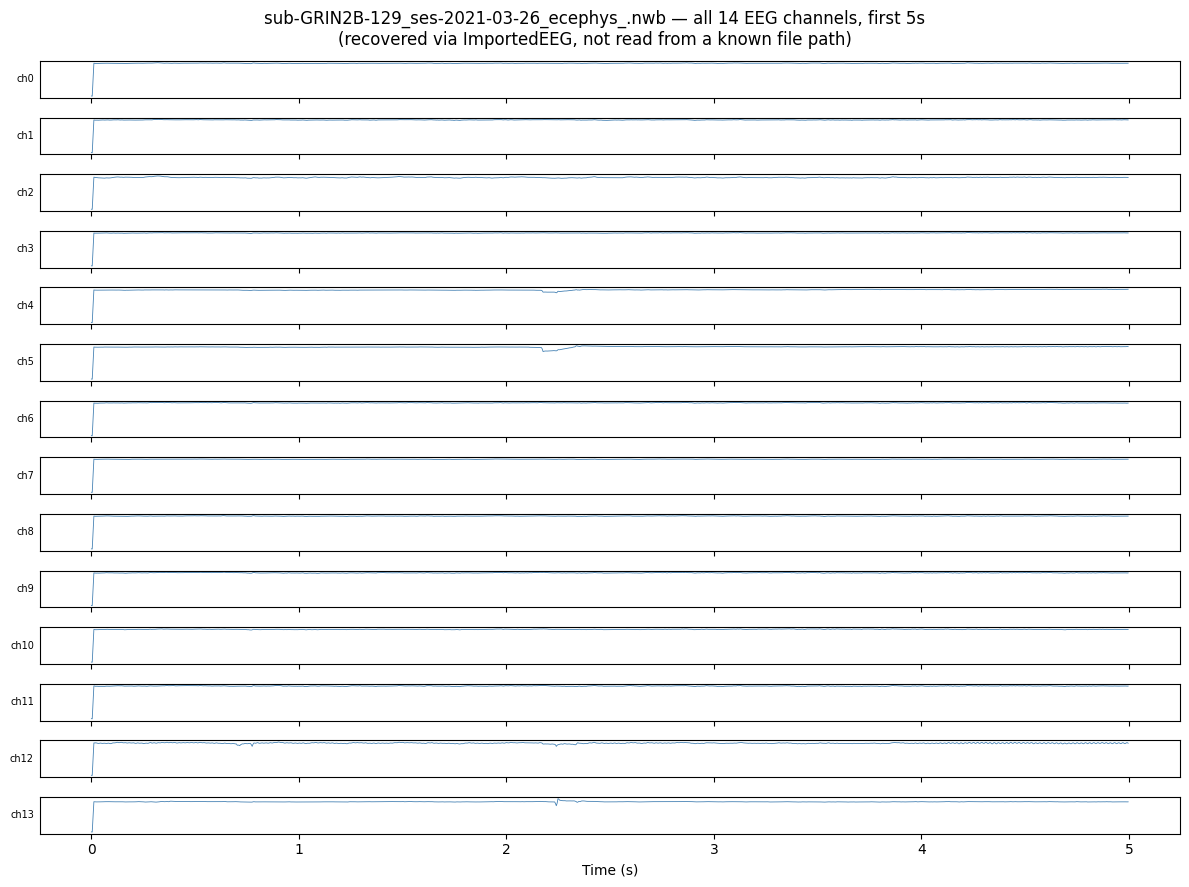

Per-channel stats over this snippet (µV) — proof the recovered array is real, analyzable data:


,mean_uV,std_uV
0,2.592104e+09,1.107302e+08
1,2.518137e+09,1.078187e+08
2,2.534627e+09,1.109977e+08
3,2.523100e+09,1.077904e+08
4,2.597416e+09,1.154334e+08
5,2.584952e+09,1.202933e+08
6,2.544766e+09,1.090570e+08
7,2.546098e+09,1.085009e+08
8,2.551294e+09,1.091458e+08
9,2.607165e+09,1.121086e+08


In [6]:
eeg_series_rows = sorted(
    (ImportedEEG() & {"name": "EEGElectricalSeries"}).fetch(as_dict=True),
    key=lambda r: r["nwb_file_name"],
)
print(f"{len(eeg_series_rows)} EEG series recovered from the database.")

example = eeg_series_rows[0]
example_series = ImportedEEG().nwb_object(
    {"nwb_file_name": example["nwb_file_name"], "eeg_object_id": example["eeg_object_id"]}
)

fs = example_series.rate
n_seconds = 5
n_samples = int(n_seconds * fs)
snippet_uv = np.asarray(example_series.data[:n_samples, :]) * 1e6  # volts -> microvolts
t = np.arange(n_samples) / fs

fig, axes = plt.subplots(snippet_uv.shape[1], 1, figsize=(12, 9), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, snippet_uv[:, i], lw=0.6, color="steelblue")
    ax.set_ylabel(f"ch{i}", fontsize=7, rotation=0, ha="right", va="center")
    ax.set_yticks([])
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"{example['nwb_file_name']} — all 14 EEG channels, first {n_seconds}s\n(recovered via ImportedEEG, not read from a known file path)")
fig.tight_layout()
plt.show()

print("Per-channel stats over this snippet (µV) — proof the recovered array is real, analyzable data:")
pd.DataFrame({"mean_uV": snippet_uv.mean(axis=0), "std_uV": snippet_uv.std(axis=0)})

### 2.2 The same brain region, across subjects, one plot

`region_index=0` is the first column of every `EEGElectricalSeries`. Before plotting, we confirm from the database — not from any recollection of the conversion code — that `region_index=0` maps to the *same* physical electrode, in the *same* brain region, in every subject: `ImportedEEG.Electrode` joined to `Electrode` (for `electrode_group_name`/`electrode_id`) and to `BrainRegion` (for `region_name`). Only once that is confirmed do we overlay traces from that region for 5 subjects.

In [7]:
joined = ImportedEEG.Electrode() * sgc.Electrode() * sgc.BrainRegion()

chan0_identity = []
for row in eeg_series_rows:
    group_name, electrode_id, region_name = (
        joined
        & {
            "nwb_file_name": row["nwb_file_name"],
            "eeg_object_id": row["eeg_object_id"],
            "region_index": 0,
        }
    ).fetch1("electrode_group_name", "electrode_id", "region_name")
    chan0_identity.append((row["nwb_file_name"], group_name, electrode_id, region_name))

chan0_df = pd.DataFrame(
    chan0_identity, columns=["nwb_file_name", "electrode_group_name", "electrode_id", "region_name"]
)
display(chan0_df)

assert chan0_df["electrode_group_name"].nunique() == 1
assert chan0_df["electrode_id"].nunique() == 1
assert chan0_df["region_name"].nunique() == 1
group_name0, electrode_id0, region_name0 = chan0_df.iloc[0][
    ["electrode_group_name", "electrode_id", "region_name"]
]
print(
    f"✓ region_index=0 is the same electrode, in the same brain region, in all {len(chan0_df)} subjects: "
    f"group={group_name0!r}, electrode_id={electrode_id0}, brain region={region_name0!r}"
)

,nwb_file_name,electrode_group_name,electrode_id,region_name
0,sub-GRIN2B-129_ses-2021-03-26_ecephys_.nwb,EEGArray,0,cortex
1,sub-GRIN2B-130_ses-2021-03-26_ecephys_.nwb,EEGArray,0,cortex
2,sub-GRIN2B-131_ses-2021-03-26_ecephys_.nwb,EEGArray,0,cortex
3,sub-GRIN2B-132_ses-2021-03-26_ecephys_.nwb,EEGArray,0,cortex
4,sub-GRIN2B-137_ses-2021-03-31_ecephys_.nwb,EEGArray,0,cortex
5,sub-GRIN2B-138_ses-2021-03-31_ecephys_.nwb,EEGArray,0,cortex
6,sub-GRIN2B-139_ses-2021-03-31_ecephys_.nwb,EEGArray,0,cortex
7,sub-GRIN2B-227_ses-2021-07-28_ecephys_.nwb,EEGArray,0,cortex
8,sub-GRIN2B-228_ses-2021-07-28_ecephys_.nwb,EEGArray,0,cortex
9,sub-GRIN2B-229_ses-2021-07-28_ecephys_.nwb,EEGArray,0,cortex


✓ region_index=0 is the same electrode, in the same brain region, in all 17 subjects: group='EEGArray', electrode_id=0, brain region='cortex'


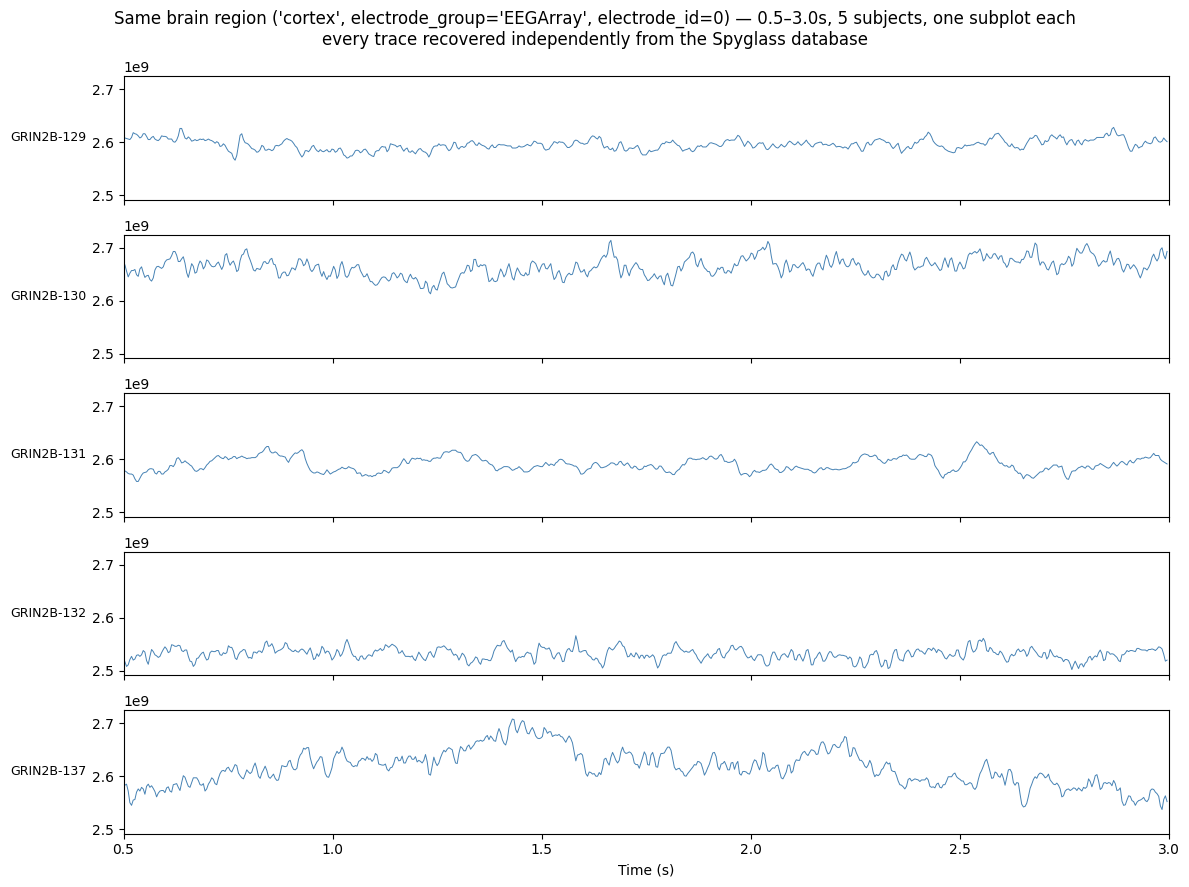

In [8]:
n_subjects_to_plot = 5
t_start, t_stop = 0.5, 3.0  # seconds

selected_rows = eeg_series_rows[:n_subjects_to_plot]

fig, axes = plt.subplots(
    n_subjects_to_plot, 1, figsize=(12, 9), sharex=True, sharey=True
)
for ax, row in zip(axes, selected_rows):
    series = ImportedEEG().nwb_object(
        {"nwb_file_name": row["nwb_file_name"], "eeg_object_id": row["eeg_object_id"]}
    )
    fs = series.rate
    start_sample = int(t_start * fs)
    stop_sample = int(t_stop * fs)
    trace_uv = np.asarray(series.data[start_sample:stop_sample, 0]) * 1e6  # volts -> microvolts
    t = np.arange(start_sample, stop_sample) / fs

    subject_label = row["nwb_file_name"].split("_")[0].replace("sub-", "")
    ax.plot(t, trace_uv, lw=0.7, color="steelblue")
    ax.set_ylabel(subject_label, fontsize=9, rotation=0, ha="right", va="center")

axes[-1].set_xlabel("Time (s)")
axes[-1].set_xlim(t_start, t_stop)
fig.suptitle(
    f"Same brain region ({region_name0!r}, electrode_group={group_name0!r}, electrode_id={electrode_id0}) — "
    f"{t_start}–{t_stop}s, {len(selected_rows)} subjects, one subplot each\n"
    "every trace recovered independently from the Spyglass database"
)
fig.tight_layout()
plt.show()

## Summary

Starting from nothing but the Spyglass database connection, this notebook:

- **Recovered and completeness-checked** every session, subject, electrode table, and `ImportedEEG` entry for all inserted GRIN2B subjects — with assertions, not just eyeballing.
- **Recovered real, analyzable trace data** for a single subject (multi-channel snippet + per-channel stats) and then **the same electrode across every subject**, overlaid on one plot — all resolved through `ImportedEEG().nwb_object()`, never a hand-typed file path.

See `../spyglass_ingestion_notes.md` for how this data got into Spyglass (target schema, empirical gap analysis, batch insertion results) and the current known gaps (`DataAcquisitionDevice`, `TaskEpoch`, derived streams).